<a href="https://colab.research.google.com/github/maryammanzoor606-ctrl/iris-data-exploration/blob/main/Maryam_Manzoor_3_tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK #1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


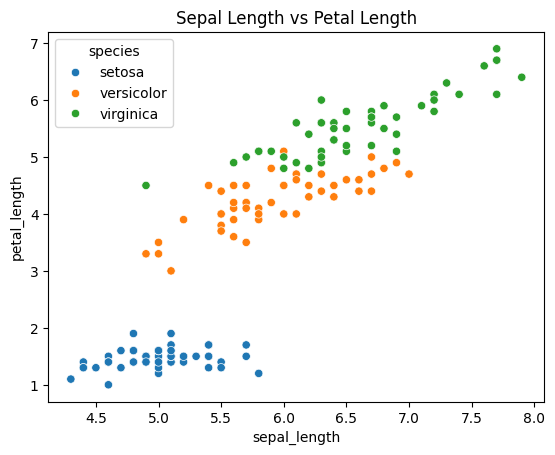

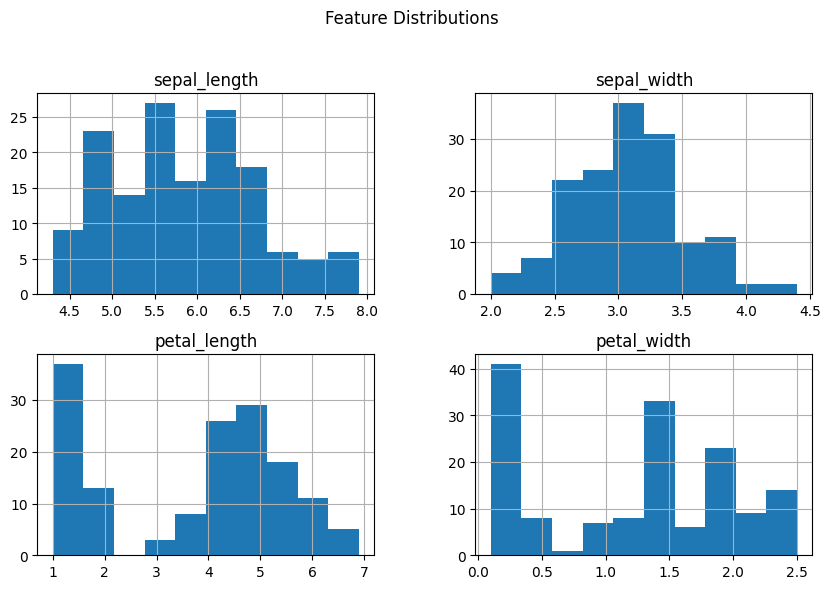

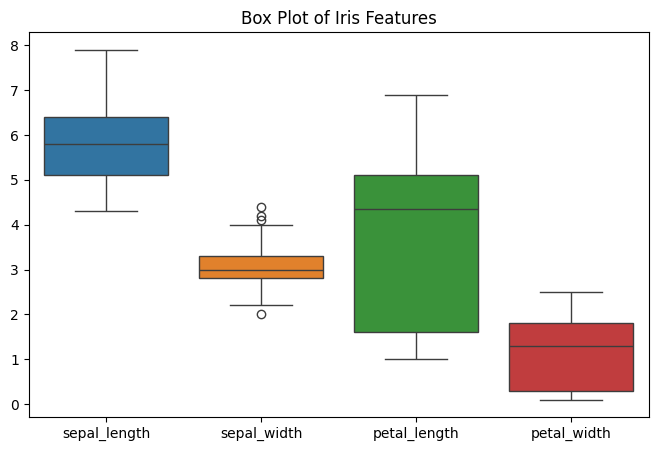

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = sns.load_dataset("iris")
# Shape of dataset
df.shape
# Column names
df.columns
# First 5 rows
df.head()
df.info()
df.describe()
sns.scatterplot(
    data=df,
    x="sepal_length",
    y="petal_length",
    hue="species"
)
plt.title("Sepal Length vs Petal Length")
plt.show()
df.hist(figsize=(10,6))
plt.suptitle("Feature Distributions", y=1.02)
plt.show()
plt.figure(figsize=(8,5))
sns.boxplot(data=df)
plt.title("Box Plot of Iris Features")
plt.show()


TASK #2



/tmp/ipython-input-379833201.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1006 entries, 2020-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1006 non-null   float64
 1   (High, AAPL)    1006 non-null   float64
 2   (Low, AAPL)     1006 non-null   float64
 3   (Open, AAPL)    1006 non-null   float64
 4   (Volume, AAPL)  1006 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 47.2 KB


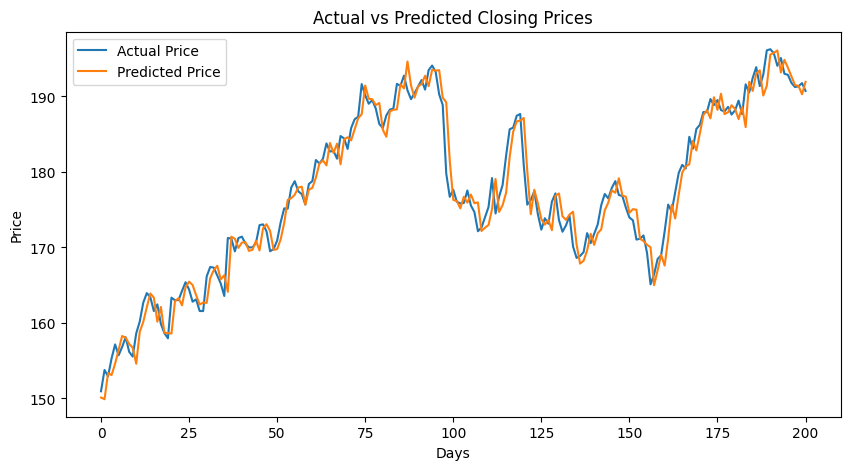

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
stock = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
stock.head()
stock.shape
stock.info()
stock.describe()
# Shift Close price to get next day target
stock["Target"] = stock["Close"].shift(-1)

# Drop last row (it will have NaN target)
stock.dropna(inplace=True)

# Features and target
X = stock[["Open", "High", "Low", "Volume"]]
y = stock["Target"]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

mae, rmse
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()


TASK #3

Saving heart.csv to heart (3).csv
Dataset Loaded
Columns: Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')
Using target column: target


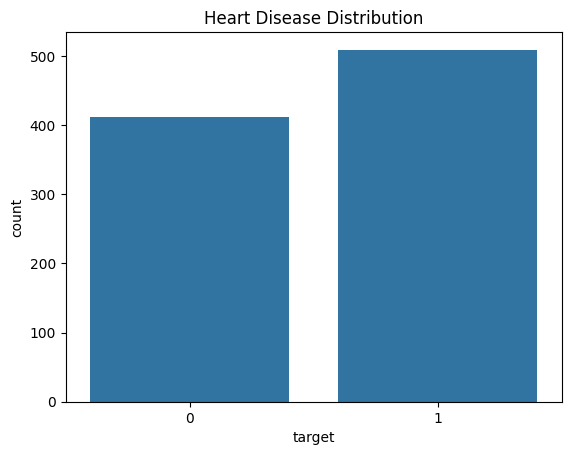

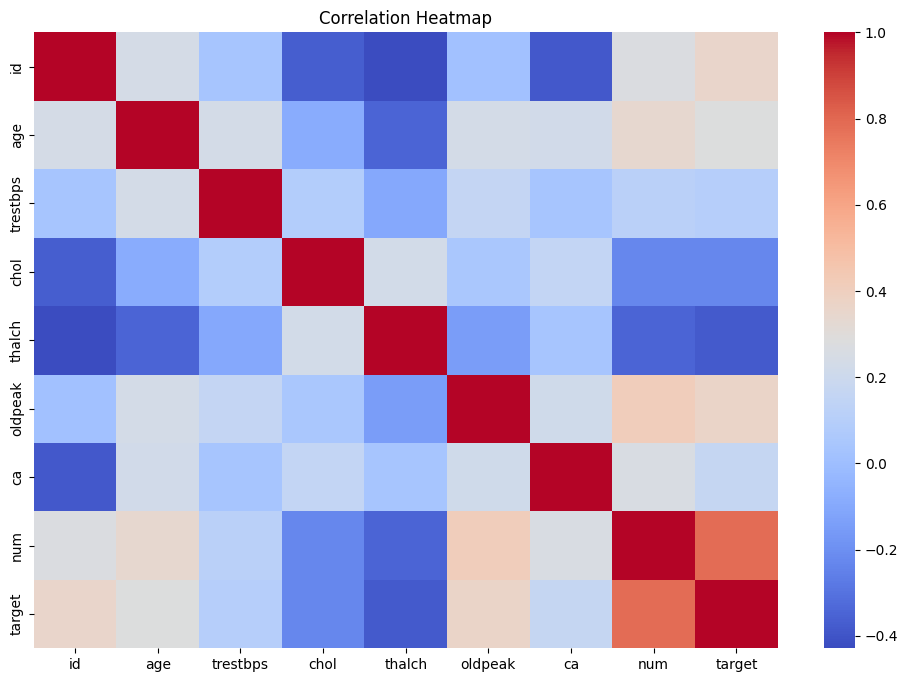

Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


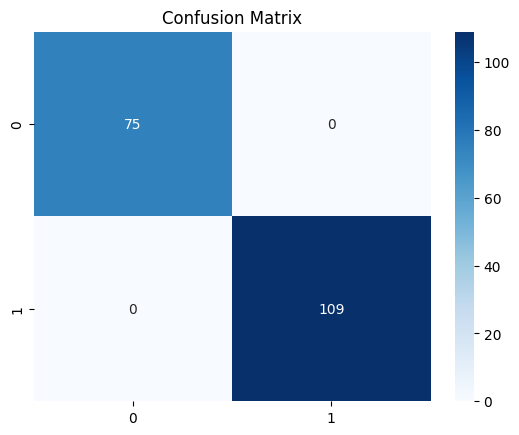

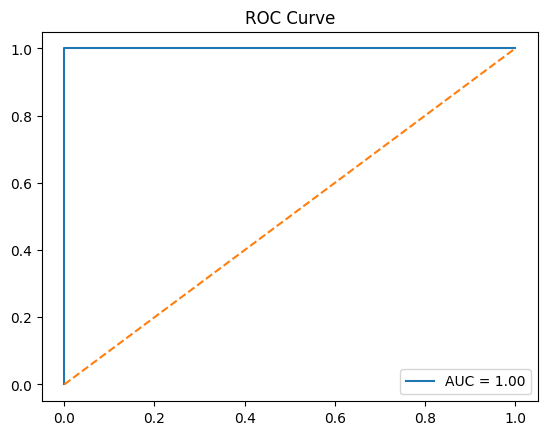

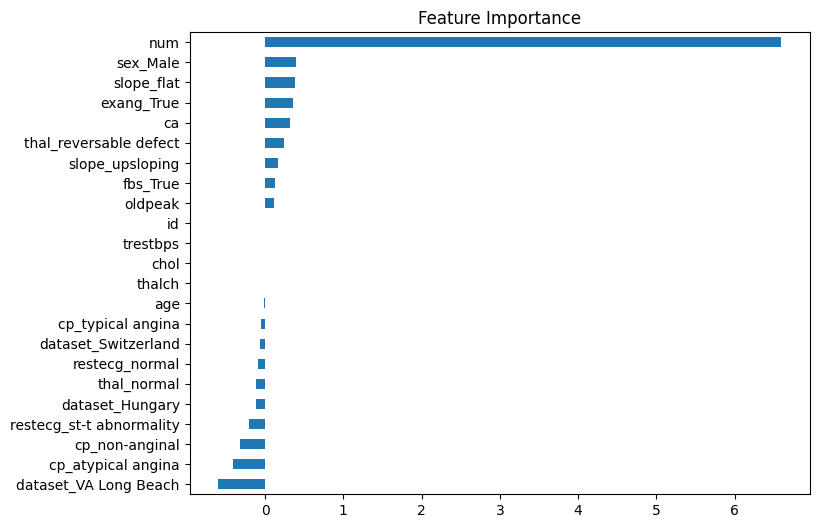

In [9]:
# ==============================
# HEART DISEASE PREDICTION (ONE CELL - FIXED NaN)
# ==============================

from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset Loaded")
print("Columns:", df.columns)

# ------------------------------
# Handle target column automatically
# ------------------------------
if "target" in df.columns:
    target_col = "target"
elif "output" in df.columns:
    target_col = "output"
elif "num" in df.columns:
    df["target"] = df["num"].apply(lambda x: 1 if x > 0 else 0)
    target_col = "target"
else:
    raise ValueError("No target/output/num column found")

print("Using target column:", target_col)

# ------------------------------
# Handle categorical columns (One-Hot Encoding)
# ------------------------------
df_encoded = pd.get_dummies(df, drop_first=True)

# ------------------------------
# Fill missing values (NaN) with median
# ------------------------------
df_encoded = df_encoded.fillna(df_encoded.median())

# ------------------------------
# EDA
# ------------------------------
sns.countplot(x=target_col, data=df)
plt.title("Heart Disease Distribution")
plt.show()

plt.figure(figsize=(12,8))
numeric_df = df_encoded.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

# ------------------------------
# Feature & target split
# ------------------------------
X = df_encoded.drop(target_col, axis=1)
y = df_encoded[target_col]

# ------------------------------
# Train-test split
# ------------------------------
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------
# Train Logistic Regression
# ------------------------------
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# ------------------------------
# Predictions
# ------------------------------
y_pred = model.predict(X_test)

# ------------------------------
# Evaluation
# ------------------------------
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

# Feature Importance
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance")
plt.show()








